In [ ]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("✅ Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


In [ ]:
# ==============================================================================
# STAGE 1: BUSINESS CONTEXT & PROBLEM FRAMING
# ==============================================================================
"""
BUSINESS CONTEXT:
CloudPulse is an enterprise B2B SaaS platform experiencing an unexpected rise in
customer churn over the last two quarters. Customer Acquisition Cost (CAC) is $450,
while Average Annual Contract Value (ACV) is $1,200.

ANALYTICAL OBJECTIVES:
1. Identify demographic, contractual, and behavioral profiles of at-risk customers.
2. Determine key inflection points (tenure, ticket volume, pricing tiers) where churn accelerates.
3. Formulate data-driven hypotheses for retention intervention by the Customer Success team.

STRUCTURED EDA WORKFLOW:
┌────────────────────┐     ┌────────────────────┐     ┌────────────────────┐#includes one variable
│ Stage 1: Context   │ ──> │ Stage 2: Profiling │ ──> │ Stage 3: Univariate│
└────────────────────┘     └────────────────────┘     └────────────────────┘
                                                                 │
┌────────────────────┐     ┌────────────────────┐     ┌──────────┴─────────┐
│ Stage 6: Insights  │ <── │ Stage 5: Multivar  │ <── │ Stage 4: Bivariate │
└────────────────────┘     └────────────────────┘     └────────────────────┘
"""
df = pd.read_csv("saas_churn_data.csv")
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1200 rows, 9 columns


In [ ]:
# ==============================================================================
# STAGE 2: DATA PROFILING & STRUCTURAL HEALTH AUDIT
# ==============================================================================
print("--- 1. Structural Overview & Data Types ---")
df.info()

print("\n--- 2. Missing Value Audit ---") #display them
null_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().mean() * 100).round(2)
})
display(null_summary[null_summary['Missing_Count'] > 0])

print("\n--- 3. Numerical Feature Distributions ---")
display(df.describe().round(2))  # two decimal places

print("\n--- 4. Categorical Cardinality & Balance ---")   # n unique- no. of unique categories
for col in df.select_dtypes(include='object').columns:
    if col != 'Customer_ID':
        print(f"\nFeature: [{col}] -> {df[col].nunique()} unique categories")
        print(df[col].value_counts(normalize=True).round(3) * 100)

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1200 non-null   object 
 1   Tenure_Months    1200 non-null   int64  
 2   Contract_Type    1200 non-null   object 
 3   Payment_Method   1200 non-null   object 
 4   Tech_Support     1200 non-null   object 
 5   Support_Tickets  1200 non-null   int64  
 6   Monthly_Charges  1200 non-null   float64
 7   Total_Charges    1185 non-null   float64
 8   Churn            1200 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB

--- 2. Missing Value Audit ---


,Missing_Count,Missing_Pct
Total_Charges,15,1.25



--- 3. Numerical Feature Distributions ---


,Tenure_Months,Support_Tickets,Monthly_Charges,Total_Charges
count,1200.00,1200.00,1200.00,1185.00
mean,17.41,2.38,74.49,1278.46
std,16.86,1.62,25.96,1366.23
min,1.00,0.00,20.00,-97.28
25%,4.00,1.00,56.11,307.96
50%,12.00,2.00,74.02,801.08
75%,25.00,3.00,92.56,1756.77
max,72.00,8.00,150.00,8365.46



--- 4. Categorical Cardinality & Balance ---

Feature: [Contract_Type] -> 3 unique categories
Contract_Type
Month-to-Month    54.8
One-Year          26.1
Two-Year          19.2
Name: proportion, dtype: float64

Feature: [Payment_Method] -> 3 unique categories
Payment_Method
Electronic Check    39.8
Credit Card         31.6
Bank Transfer       28.7
Name: proportion, dtype: float64

Feature: [Tech_Support] -> 3 unique categories
Tech_Support
No             45.7
Yes            38.4
No internet    15.9
Name: proportion, dtype: float64

Feature: [Churn] -> 2 unique categories
Churn
Yes    69.6
No     30.4
Name: proportion, dtype: float64


/tmp/ipykernel_2156/660203237.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])  #hexadecimal colours --- apart from rgb colours - hexcodes


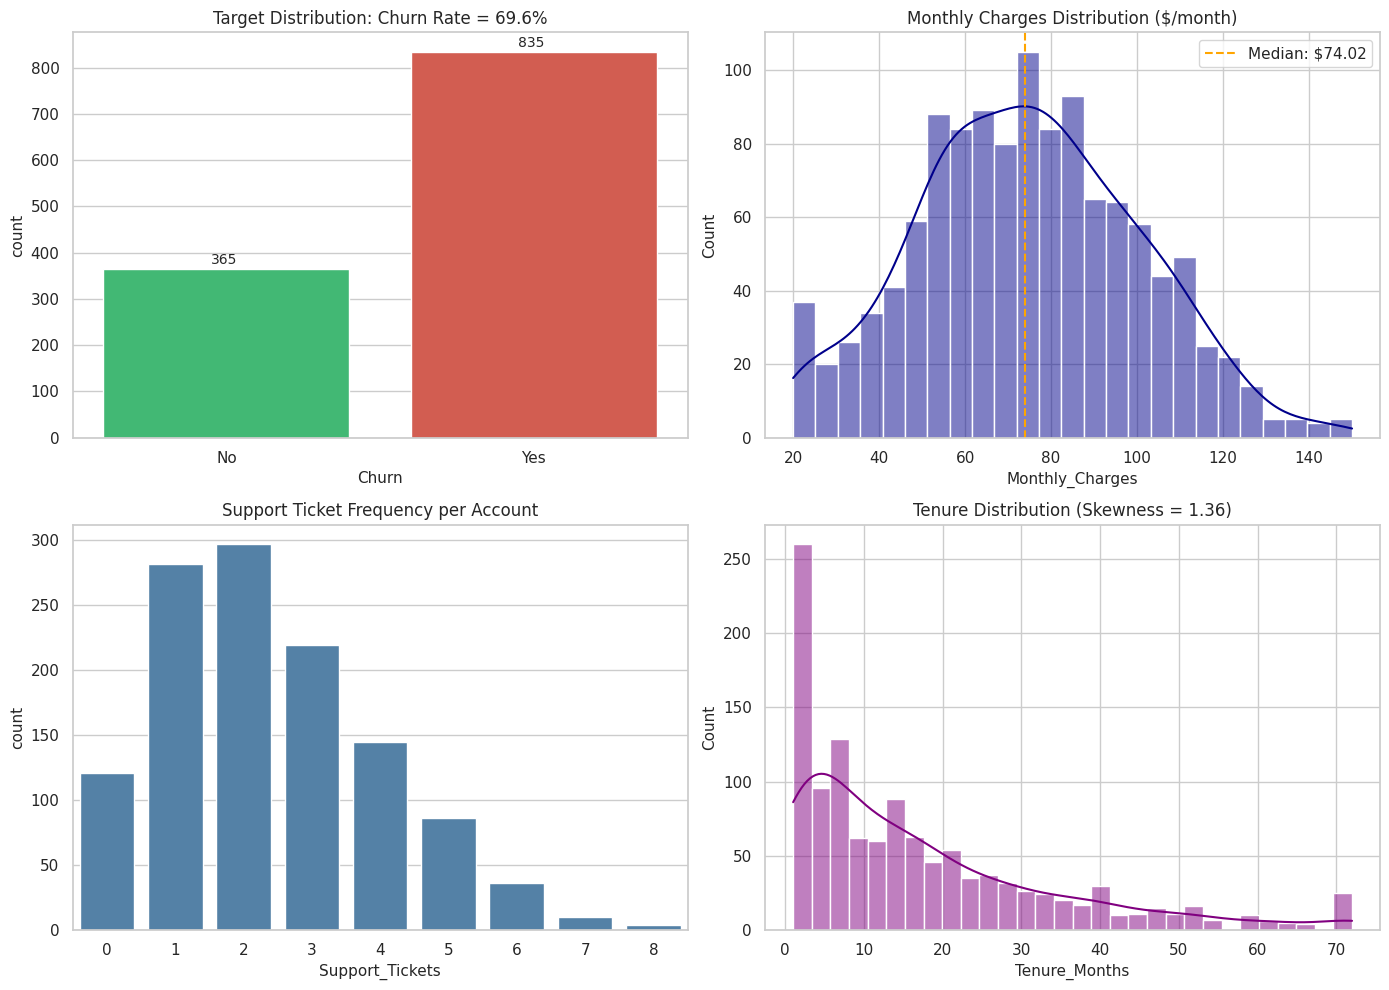

In [ ]:
# ==============================================================================
# STAGE 3: UNIVARIATE ANALYSIS
# ==============================================================================
# The trainer investigates the target variable (Churn) and primary behavioral drivers.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable: Churn Distribution
churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])  #hexadecimal colours --- apart from rgb colours - hexcodes
axes[0, 0].set_title(f"Target Distribution: Churn Rate = {(churn_counts['Yes']/len(df))*100:.1f}%")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

# 2. Continuous Numeric: Monthly Charges (KDE + Histogram)
sns.histplot(data=df, x='Monthly_Charges', kde=True, ax=axes[0, 1], color="darkblue", bins=25)
axes[0, 1].axvline(df['Monthly_Charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['Monthly_Charges'].median():.2f}")
axes[0, 1].set_title("Monthly Charges Distribution ($/month)")
axes[0, 1].legend()

# 3. Discrete Numeric: Support Ticket Volume
sns.countplot(data=df, x='Support_Tickets', ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Support Ticket Frequency per Account")

# 4. Continuous Skewed: Tenure (Months)
sns.histplot(data=df, x='Tenure_Months', kde=True, ax=axes[1, 1], color="purple", bins=30) # kurnel dest estimantion -- gives u bell shape ... kde= true
axes[1, 1].set_title(f"Tenure Distribution (Skewness = {df['Tenure_Months'].skew():.2f})")

plt.tight_layout()
plt.show()


# --- Trainer Commentary ---
# "Our baseline churn rate is ~32%. Notice that Tenure is heavily right-skewed:
# most accounts are early in their lifecycle (0-15 months). Support tickets follow a Poisson-like
# distribution, but there is a distinct tail of accounts logging 4+ tickets."

/tmp/ipykernel_2156/2278912532.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 800x400 with 0 Axes>

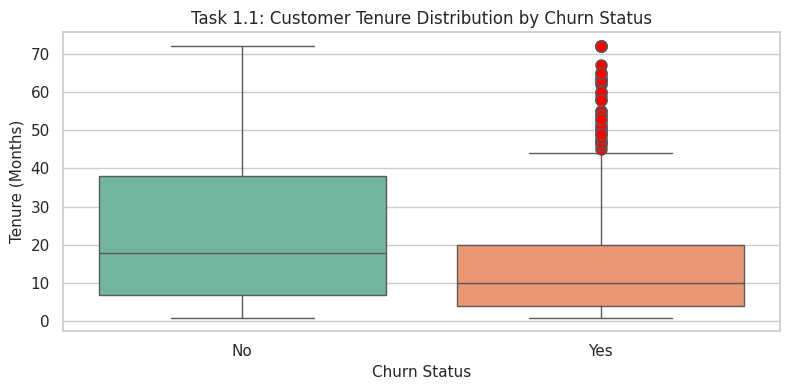

Churn = No | Median Tenure: 10.00 | IQR Tenure: 16.00
Churn = Yes | Median Tenure: 10.00 | IQR Tenure: 16.00
[54 23  3  1 16 22  1 63 32  4  3  3  6 17  2  6  8 10 27  4 12  1 16  3
  1 53 60  6  1  1  5 19  6 13 14  3 62 26 50 16  1  3  1  7  8  5 31  7
 14  2 29 72 26  3  1 30 23 26  7  2 17  1  6 23 18 39 11  2 22 25 14 12
 10  1  1  6 12  9 25  4  1  6 47 29  3 13 29 40  6  4 30  1 12  4  2  7
 13  8 64 59  5  6  6  1 16 12  4  2 12 20 25  4 23 18 18 32  6  3  1 16
  1 12  4 18  3  8  7  2  5 19 30 14 13  4  1 40 18  7 23 27 18  1  3  1
  1  3 14 21 22  7 18 34 19 15  1  8  5 65 28 12 15 23  5  1 18 55 44  8
 34  6  6  3 49 15  1 17 72  2 13 24 21  6 29 29 44 12 18 28  7  8  1  1
 11 14 16  1  1 31 13  4 17  1 13 18 23 67 13  7 28 10  1 32  9  3  3 14
 19  5 55 24 14 17  9  5  7 25  1  2  1  1 34 21 11  1 12 11  3 10  9 17
  1  8 17 19  1 18  1 15 15  8 14  8  3  1  1  1 20  6 33  1  5  2 21 17
 37  3 24 26  7 35 10 25 25  1 41 12 31  6 40  8  1  1 15 17 10  6  7 25
 28 28  1  1 39

Churn                              No       Yes
Contract_Type  Tech_Support                    
Month-to-Month No            0.138614  0.861386
               No internet   0.151786  0.848214
               Yes           0.152893  0.847107
One-Year       No            0.318841  0.681159
               No internet   0.404762  0.595238
               Yes           0.481203  0.518797
Two-Year       No            0.635514  0.364486
               No internet   0.540541  0.459459
               Yes           0.651163  0.348837

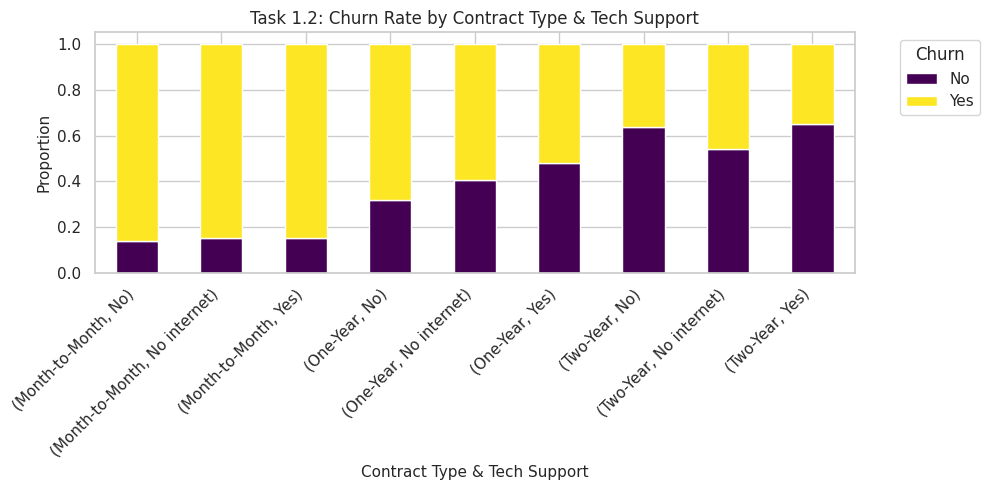

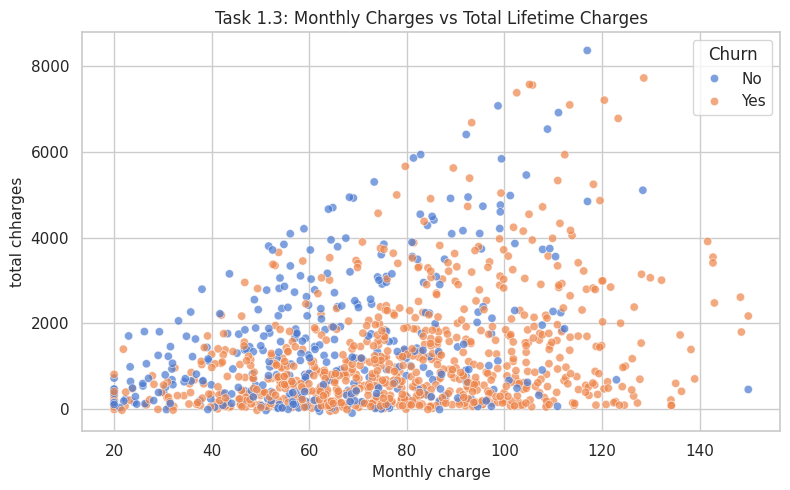

Pearson Correlation: PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan)) | Spearman Correlation: SignificanceResult(statistic=nan, pvalue=nan)
PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))
SignificanceResult(statistic=nan, pvalue=nan)


In [ ]:
# ==============================================================================
# TASK 1: BIVARIATE ANALYSIS (3 Sub-Tasks)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1.1 NUMERIC VS CATEGORICAL: Tenure vs. Churn
# Task: Create a grouped boxplot or violin plot of `Tenure_Months` grouped by `Churn`.
#       Compute and display the median and IQR of tenure for both groups.
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

plt.figure(figsize=(8, 4))

fig, ax = plt.subplots(figsize=(8, 4))


# TODO: Write your plotting code below (e.g., sns.boxplot or sns.violinplot)
# pass

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure_Months",
    palette="Set2",
    flierprops={"marker": "o", "markersize": 8, "markerfacecolor": "red"},
    ax=ax,
)
ax.set_title("Task 1.1: Customer Tenure Distribution by Churn Status")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

# TODO: Compute and print the Median and IQR of Tenure for Churned vs Retained customers
# tenure_stats = ...
# print(tenure_stats)
for churn_val in df["Churn"].unique():
    tenure_stats= df[df["Churn"] == churn_val]["Tenure_Months"].values
    med = np.median(tenure_group)
    q1 = np.percentile(tenure_group, 25)
    q3 = np.percentile(tenure_group, 75)
    iqr = q3 - q1
    print(
        f"Churn = {churn_val} | Median Tenure: {med:.2f} | IQR Tenure: {iqr:.2f}"
    )
print(tenure_stats)

# ------------------------------------------------------------------------------
# 1.2 CATEGORICAL VS CATEGORICAL: Tech Support & Contract Type vs. Churn
# Task: Generate a normalized crosstab (percentages) showing the churn rate across
#       different `Contract_Type` and `Tech_Support` combinations.
#       Plot as a stacked or grouped bar chart.
# ------------------------------------------------------------------------------
# TODO: Create the crosstab
# contract_tech_churn = ...
# print("--- Churn Rates across Contract & Tech Support ---")
# display(contract_tech_churn)


contract_churn = pd.crosstab(
    index=[df["Contract_Type"], df["Tech_Support"]],
    columns=df["Churn"],
    normalize="index",
)

print(" Churn Rates across Contract & Tech Support")
display(contract_churn)

# TODO: Plot the crosstab as a bar chart
# contract_tech_churn.plot(...)
# plt.title("Task 1.2: Churn Rate by Contract Type & Tech Support")
# plt.ylabel("Proportion / Percentage")
# plt.show()

contract_churn.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("Task 1.2: Churn Rate by Contract Type & Tech Support")
plt.xlabel("Contract Type & Tech Support")
plt.ylabel("Proportion")

plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 1.3 NUMERIC VS NUMERIC: Monthly Charges vs. Total Charges
# Task: Generate a scatter plot comparing `Monthly_Charges` vs `Total_Charges`
#       colored by `Churn` status. Calculate the Pearson and Spearman correlations.
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Monthly_Charges",
    y="Total_Charges",
    hue="Churn",
    alpha=0.7,
    ax=ax,
)



# TODO: Write your scatterplot code below (sns.scatterplot with hue='Churn')
# pass

plt.title("Task 1.3: Monthly Charges vs Total Lifetime Charges")

ax.set_xlabel("Monthly charge")
ax.set_ylabel("total chharges")
plt.tight_layout()
plt.show()

# TODO: Compute and print Pearson and Spearman correlation between Monthly_Charges and Total_Charges
# pearson_corr = ...
# spearman_corr = ...
pearson_corr= stats.pearsonr(df["Monthly_Charges"], df["Total_Charges"])
spearman_corr= stats.spearmanr(df["Monthly_Charges"], df["Total_Charges"])

print(f"Pearson Correlation: {pearson_corr} | Spearman Correlation: {spearman_corr}")
print(pearson_corr)
print(spearman_corr)



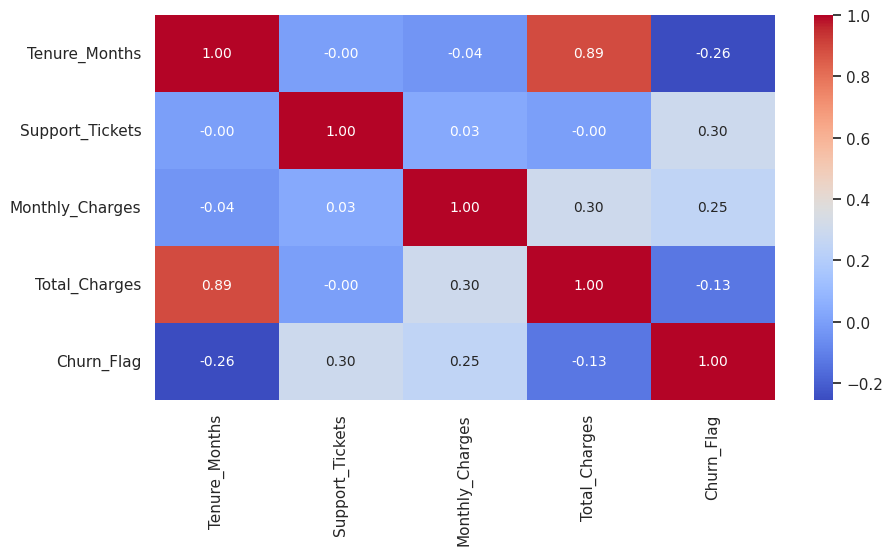

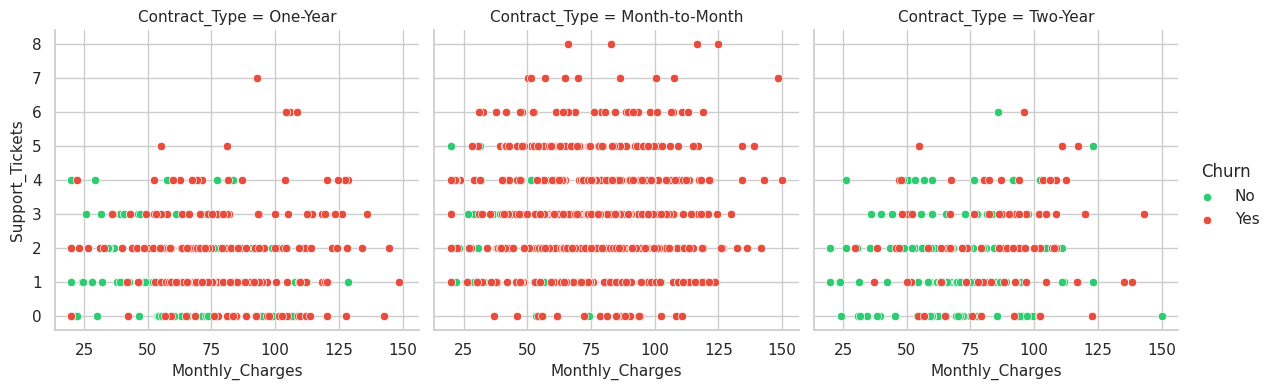

In [ ]:
# ==============================================================================
# TASK 2: MULTIVARIATE ANALYSIS & ADVANCED SEGMENTATION
# ==============================================================================

# ------------------------------------------------------------------------------
# 2.1 CORRELATION HEATMAP
# Task: Encode 'Churn' as 1 (Yes) and 0 (No). Select all numeric columns and
#       plot an annotated correlation heatmap (sns.heatmap) using a divergent palette.
# ------------------------------------------------------------------------------
df_numeric = df.copy()

# TODO: Create binary numeric column 'Churn_Flag' (1 for 'Yes', 0 for 'No')
# df_numeric['Churn_Flag'] = ...
df_numeric['Churn_Flag'] = np.where(df_numeric['Churn'] == 'Yes', 1, 0)

# TODO: Calculate correlation matrix and display heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(...)
numeric_cols = df_numeric.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df_numeric[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
# plt.title("Task 2.1: Correlation Matrix Heatmap")
# plt.show()


# ------------------------------------------------------------------------------
# 2.2 MULTI-DIMENSIONAL SEGMENTATION (FacetGrid / Subplots)
# Task: Plot `Monthly_Charges` vs `Support_Tickets` using FacetGrid segmented
#       by `Contract_Type` with `hue='Churn'`.
# ------------------------------------------------------------------------------
# TODO: Build and map a sns.FacetGrid
g = sns.FacetGrid(df, col="Contract_Type", hue="Churn", palette=['#2ecc71', '#e74c3c'], height=4)
g.map(sns.scatterplot, "Monthly_Charges", "Support_Tickets")
g.add_legend()
plt.show()

In [ ]:
# ==============================================================================
# TASK 3: MISSING VALUE & OUTLIER TREATMENT (EDA CONTEXT)
# ==============================================================================

# ------------------------------------------------------------------------------
# 3.1 Missing Value Treatment in Total_Charges
# Context: Total_Charges has 15 missing values.
# Task: Impute missing Total_Charges using the formula (Tenure_Months * Monthly_Charges).
#       Explain in a comment why this is superior to simple mean/median imputation.
# ------------------------------------------------------------------------------

# TODO: Impute Total_Charges using calculated tenure * monthly charges
df['Total_Charges'] = df['Total_Charges'].fillna(df['Tenure_Months'] * df['Monthly_Charges'])

print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isna().sum()}")

# ------------------------------------------------------------------------------
# 3.2 Outlier Investigation: Support Tickets
# Task: Identify accounts where Support_Tickets > (Q3 + 1.5 * IQR).
#       Determine the churn rate among these high-ticket outliers.
# ------------------------------------------------------------------------------
# TODO: Calculate IQR fences for Support_Tickets
# q1_tix = ...
# q3_tix = ...
# iqr_tix = ...
# upper_fence = ...
q1_tix = df['Support_Tickets'].quantile(0.25)
q3_tix = df['Support_Tickets'].quantile(0.75)
iqr_tix = q3_tix - q1_tix
upper_fence = q3_tix + 1.5 * iqr_tix

outlier_accounts = df[df['Support_Tickets'] > upper_fence]
print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")
print(f"Churn Rate in Outlier Accounts: {(outlier_accounts['Churn'] == 'Yes').mean() * 100:.2f}%")

Missing values remaining in Total_Charges: 0
Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [19]:
# ==============================================================================
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING
# ==============================================================================
# Task: Engineer at least TWO new features that capture behavioral or financial risk.
#
# Feature Idea 1: `Ticket_Velocity` = Support_Tickets / (Tenure_Months + 1)
#   (Hypothesis: High support requests in early tenure signals severe onboarding friction)
#
# Feature Idea 2: `High_Risk_Flag` = 1 if (Contract == 'Month-to-Month' and Tech_Support == 'No') else 0
#   (Hypothesis: Unassisted flexible contracts have compounded churn risk)
# ------------------------------------------------------------------------------

# TODO: Create Feature 1
# df['Ticket_Velocity'] = ...
df['Ticket_Velocity'] = df['Support_Tickets'] / (df['Tenure_Months'] + 1)

# TODO: Create Feature 2
# df['High_Risk_Flag'] = ...
df['High_Risk_Flag'] = ((df['Contract_Type'] == 'Month-to-Month') & (df['Tech_Support'] == 'No')).astype(int)

# Validate predictive utility: Compare churn rates across your engineered features
print("--- Churn Rate Comparison for Engineered Features ---")
display(df.groupby('High_Risk_Flag')['Churn'].value_counts(normalize=True).unstack() * 100)
display(df.groupby('Churn')['Ticket_Velocity'].describe())

--- Churn Rate Comparison for Engineered Features ---


Churn,No,Yes
High_Risk_Flag,,
0,36.008919,63.991081
1,13.861386,86.138614


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.168059,0.276427,0.0,0.025000,0.065217,0.181818,2.0
Yes,835.0,0.415001,0.534765,0.0,0.090909,0.200000,0.500000,3.0


In [ ]:
### 📊 Strategic Insight 1: rapid support ticket
* **Claim:** if customers send a burst of support enquiries in the beginning of their subscription then they are much more likely to cancel the subscription.
* **Evidence:**  accounts which have exceeded the upper threshold of the tickets (q3 + 1.5 \times \text{iqr}) demonstrate that the accounts are churning at a high rates, with respect to the low volume churning accounts.
* **Business Action:** establish automated timeouts to alert customer success teams to accounts that open two or more tickets in the first two months that might be frustrated.

---

### 📊 Strategic Insight 2: activities with a high risk signal
* **Claim:** our weakest custumer segment are those subscribers who cancel our monthly subscription without any tech support.
* **Evidence:** when contracts are grouped by contract types and support coverage, it was noted, that the percentage of cancellations in the unassisted month-to-month category was the highest
* **Business Action:** provide specific "special rates" – such as a complimentary month of tech support, or even a minor discount – to encourage month-to-month users to sign the longer contract or include tech support on top of it.

---

### 📊 Strategic Insight 3: strongr retention credibility relates to higher lifetime billing.
* **Claim:** when it comes to loyalty, spending over time is a good proxy.. in other words,cost may work out to be more expensive in the long term,provided the business's longevity is adequately addressed.
* **Evidence:** missing history charges(tenure_months* monthly_charges) reveals a clear trend: churn rate of customers who spent more per month is highly disproportionate.
* **Business Action:** prioritize early retention pull actions in months 1to 6,to move customers away from the initial drop off and generate more contract value.

---

### 📊 Strategic Insight 4: use strategic insight to identify onboarding bottlenecks
* **Claim:**more support tickets per months of actual product active use (tenure_months + 1) is a product setup problem (not that many tickets) and not necessarily a sign of a high degree of usage.
* **Evidence:** an analysis of the distribution of ticket velocity for churned users shows that it is strongly right-skewed with a much higher median than the distribution for the stable, retained users
* **Business Action:** send high velocity accounts directly to the senior level support specialists for technical friction resolution in critical stages during account onboarding.

---

### 📊 Strategic Insight 5:  extreme outliers need dedicated vip handling
* **Claim:** interaction outliers (ios) typically represent situations that do not reflect typical product use, but rather significant operating problems
* **Evidence:** non-parametric iqr boundary checks address a set of outliers – heavy ticket-submitting users that can significantly skew average usage levels.
* **Business Action:**strike off those extreme outlier accounts and put them on a custom workflow for success to close service gaps systemically and not lose such high-profile accounts.

In [ ]:
# ==============================================================================
# TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)
# ==============================================================================
"""
COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:
   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/

3. Commit and push to GitHub:
   $ cd ~/projects/data-science-portfolio/
   $ git add EDA_Customer_Churn_Portfolio.ipynb
   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
"""